
# Reinforcement Learning Control for a 2-DOF Helicopter

This notebook implements a reinforcement learning control (RL) strategy of a nonlinear two-degrees-of-freedom (2-DOF) helicopter system for tracking the desired trajectory described in `[1]`. The RL controller was tested on the nonlinear equations of motion, while simulating the closed-loop vehicle dynamics using [c4dynamics](https://github.com/c4dynamics/c4dynamics). The primary objective is to design a controller capable of accurately tracking desired pitch and yaw trajectories while accounting for nonlinear dynamics, parametric uncertainties, and practical state constraints. 

## 1.  System Model

The system under consideration is a laboratory-scale 2-DOF helicopter, which can rotate in pitch and yaw directions and is actuated by two independent DC motors generating thrust forces. The system exhibits strong nonlinear coupling between these two axes. These characteristics make the control problem particularly challenging, as the controller must handle nonlinearities, coupling effects, and incomplete knowledge of the system while maintaining stable and accurate trajectory tracking.

<div style="text-align: center;">
  <img src="helicopter_diagram.png" alt="alt text" style="width: 50%;">
  <figcaption>Figure 1: Helicopter diagram</figcaption>
</div>

### Helicopter dynamics

The dynamics are derived using Lagrangian mechanics and result in a nonlinear multi-input multi-output (MIMO) system. The 2-DOF helicopter system equations of motion can be written as `[1]`:

$$
(J_p + M \cdot L_{cm}^2) \cdot \ddot{\theta} = K_{pp} \cdot V_p + K_{py} \cdot V_y - M \cdot g \cdot L_{cm} \cdot \cos(\theta) - D_p \cdot \dot{\theta} - M \cdot L_{cm}^2 \cdot \dot{\psi}^2 \cdot \sin(\theta) \cdot \cos(\theta)
$$
 
$$
(J_y + M \cdot L_{cm}^2 \cdot \cos^2(\theta)) \cdot \ddot{\psi} = K_{yp} \cdot V_p + K_{yy} \cdot V_y - D_y \cdot \dot{\psi} + 2 \cdot M \cdot L_{cm}^2 \cdot \dot{\psi} \cdot \dot{\theta} \cdot \sin(\theta) \cdot \cos(\theta)
$$

where $\theta$, $\psi$, $\dot{\theta}$, and $\dot{\psi}$ are the states of the system, denoted as pitch angle, yaw angle, pitch angular velocity, and yaw angular velocity, respectively; $V_p$ and $V_y$ are the input voltages of the two motors, respectively. 

Additionally, $D_p$ and $D_y$ are the viscous friction constants of pitch and yaw, respectively; $J_p$ and $J_y$ denote the moments of inertia of the pitch axis and yaw axis, respectively; $K_{pp}$, $K_{py}$, $K_{yp}$, and $K_{yy}$ are torque thrust gains acting on the pitch axis from the pitch propeller, pitch axis from the yaw propeller, yaw axis from the pitch propeller, and yaw axis from the yaw propeller, respectively. In addition, $g$ is the gravitational acceleration, $L_{cm}$ denotes the center-of-mass distance from the body-fixed frame origin, and $M$ is the mass of the helicopter.

- Import required libraries

In [734]:
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.integrate import solve_ivp
import c4dynamics as c4d

- Define system parameters

In [735]:
# Helicopter physical parameters
Jp  = 0.0215          # pitch moment of inertia          [kg·m²]
Jy  = 0.0237          # yaw moment of inertia            [kg·m²]
Dp  = 0.0171          # pitch viscous damping            [N/V]
Dy  = 0.232           # yaw viscous damping              [N/V]
Kpp =  0.0015         # thrust gain: pitch←pitch prop    [N·m/V]
Kpy =  0.0021         # thrust gain: pitch←yaw prop      [N·m/V]
Kyp = -0.0027         # thrust gain: yaw←pitch prop      [N·m/V]
Kyy =  0.0014         # thrust gain: yaw←yaw prop        [N·m/V]
Lcm =  0.0071         # centre-of-mass arm length        [m]
M   =  1.075          # total helicopter mass            [kg]
g   =  9.81           # gravitational acceleration       [m/s²]


The states are defined as $ x = [\theta, \psi, \dot{\theta}, \dot{\psi}]^T$. By defining $x_1 = [\theta, \psi]$ and $x_2 = [\dot{\theta}, \dot{\psi}]$,  the equations of motion can be expressed in state-space form:

$$
\dot{x}_1 = x_2
$$

$$
\dot{x}_2 = F(x_1, x_2) + G(x_1)\cdot u
$$

- Define initial states

In [736]:
theta0 = 0.0  # [rad]
psi0 = 0.0  # [rad]
thetadot0 = 0.0  # [rad/s]
psidot0 = 0.0  # [rad/s]

- Use `c4dynamics.state` to define and store the vehicle states during simulation

In [737]:
heli = c4d.state(theta=theta0, psi=psi0, dtheta=thetadot0, dpsi=psidot0)

- Define inputs as parameters

In [738]:
heli.Vpitch = 0.0 # [V]
heli.Vyaw = 0.0 # [V]

- Compute helicopter dynamics matrices

In [739]:
def helicopter_dynamics_matrices(x1: np.ndarray, x2: np.ndarray):
    theta, _     = x1
    dtheta, dpsi = x2

    beta1  = Jp + M * Lcm**2
    beta2  = (- M * g * Lcm * np.cos(theta)
              - Dp * dtheta
              - M * Lcm**2 * dpsi**2 * np.sin(theta) * np.cos(theta))

    gamma1 = Jy + M * Lcm**2 * np.cos(theta)**2
    gamma2 = (- Dy * dpsi
              + 2.0 * M * Lcm**2 * dpsi * dtheta * np.sin(theta) * np.cos(theta))

    F = np.array([beta2 / beta1,
                  gamma2 / gamma1])

    G = np.array([[Kpp / beta1,  Kpy / beta1],
                  [Kyp / gamma1, Kyy / gamma1]])

    return F, G


- Compute helicopter dynamics

In [740]:
def helicopter_dynamics(t: float, y: np.ndarray, u: np.ndarray):
    x1 = y[:2]
    x2 = y[2:]

    F, G  = helicopter_dynamics_matrices(x1, x2)
    dx1   = x2
    dx2   = F + G @ u
    return np.concatenate([dx1, dx2])

## 2. Controller Design  

This example implements an **Actor–Critic Reinforcement Learning architecture**, which has three main components:

- **RBF Neural Networks**: radial basis function neural networks are used to approximate unknown system dynamics, enabling the controller to compensate for uncertainties without requiring an explicit model
- **Critic Network**: the critic network evaluates the quality of the control performance by estimating a long-term cost function
- **Actor Network**: the actor network generates control inputs that aim to minimize this cost

Additionally, a barrier Lyapunov function is incorporated to enforce state constraints by penalizing trajectories that approach unsafe regions. This combination of learning, approximation, and stability-based design results in a unified control strategy that is both flexible and robust.

### Radial Basis Function Neural Networks (RBFNNs)

Radial Basis Function Neural Networks are a class of function approximators that are widely used in adaptive control due to their simplicity and strong approximation capabilities. An RBFNN represents a nonlinear function as a weighted sum of radial basis functions, typically Gaussian functions centered at different points in the input space. Because of their localized response, these networks can approximate complex nonlinear mappings with relatively simple structures and fast training.

In this work, both the critic and actor use Radial Basis Function Neural Networks (RBFNNs) as linear-in-weights function approximators:

$$
f(Z) = W^T H(Z)
$$

$$
h_i(Z) = \exp\left(-\frac{\|Z - c_i\|^2}{b^2}\right)
$$

In [741]:
def rbf_basis(Z: np.ndarray, centers: np.ndarray, width: float) -> np.ndarray:
    diff = Z - centers                             
    return np.exp(-np.sum(diff**2, axis=1) / width**2)

- Evaluates the gradient of Gaussian RBFs $\nabla H(Z)$ with respect to the input vector, used in computing learning signals and temporal-difference updates

In [742]:
def rbf_gradient(Z: np.ndarray, centers: np.ndarray,
                 width: float, H: np.ndarray) -> np.ndarray:
    diff = Z - centers                          
    return H[:, None] * (-2.0 * diff / width**2)

- Constructs a set of RBF centers $c_i$ over the state/input domain, enabling localized Gaussian basis functions for accurate nonlinear function approximation

In [743]:
def make_centers(n_nodes: int, input_dim: int,
                 bounds: list, rng: np.random.Generator) -> np.ndarray:
    lo = np.array([b[0] for b in bounds])
    hi = np.array([b[1] for b in bounds])
    return rng.uniform(0, 1, size=(n_nodes, input_dim)) * (hi - lo) + lo

###  Critic

The critic network plays a central role in the reinforcement learning framework by estimating a long-term cost function that reflects the quality of the control performance over time. By approximating this function using a neural network, the critic can evaluate how good a particular control policy is and provide feedback to guide improvement. The learning process is based on minimizing the difference between the predicted and actual cost evolution, allowing the critic to refine its estimate as the system evolves.

Computes instantaneous cost $I(t) = z_1^T Q z_1 + u^T R u$, forms the temporal-difference residual $\phi$, and updates critic weights $W_c$ by gradient descent. It finally returns the estimated cost-to-go $\hat{J}$.

In [744]:
def critic_update(Wc: np.ndarray,
                  Hc: np.ndarray, grad_Hc: np.ndarray,
                  z1: np.ndarray, z2: np.ndarray,
                  u: np.ndarray,
                  Q: np.ndarray, R: np.ndarray,
                  zeta: float, lc: float, dt: float):
    I_t    = float(z1 @ Q @ z1 + u @ R @ u)
    z1_dot = z2
    Lambda = -Hc / zeta + grad_Hc @ z1_dot         
    phi    = I_t + Wc @ Lambda                     
    Wc     = Wc - lc * phi * Lambda * dt
    J_hat  = float(Wc @ Hc)
    return Wc, J_hat

### Actor

The actor network is responsible for generating the control input based on the current system state and the information provided by the critic. Its objective is to produce actions that minimize the long-term cost estimated by the critic, effectively improving control performance over time. In this work, the actor incorporates both the backstepping-based control structure and the neural network approximation of unknown dynamics, resulting in a control law that is both adaptive and learning-driven. The actor’s parameters are updated using a gradient-based rule that considers states, inputs and the critic’s evaluation, enabling the controller to balance immediate performance with long-term optimization.

####  Backstepping

Backstepping is a recursive control design technique commonly used for nonlinear systems, where the control problem is broken down into a sequence of smaller steps. Instead of directly designing the final control input, the method first introduces intermediate or "virtual" control laws that stabilize lower-order subsystems, and then progressively builds toward the actual control input. The main advantage of backstepping is that it provides a systematic way to handle nonlinearities while maintaining rigorous stability guarantees.

Compute backstepping error signals and the virtual control α.


$$
z_1 = x_1 - x_d
$$

$$
\alpha = -K_1 z_1 + \dot{x}_d
$$

$$
z_2 = x_2 - \alpha
$$

$$
\dot{\alpha} = -K_1 (x_2 - \dot{x}_d) + \ddot{x}_d
$$


In [745]:
def backstepping(x1: np.ndarray, x2: np.ndarray,
                 xd: np.ndarray, xd_d: np.ndarray,
                 xd_dd: np.ndarray, K1: np.ndarray):
    z1      = x1 - xd
    alpha   = -K1 @ z1 + xd_d
    z2      = x2 - alpha
    alpha_d = -K1 @ (x2 - xd_d) + xd_dd
    return z1, z2, alpha_d

####  Barrier Lyapunov Function (BLF)

To ensure that the system states remain within predefined safety limits, a barrier Lyapunov function is introduced into the control design. Unlike standard Lyapunov functions, which typically penalize large errors, the barrier Lyapunov function becomes unbounded as the system approaches constraint boundaries, effectively preventing the states from violating these limits. This creates a virtual "barrier" that restricts the evolution of the system within a safe region. In practice, this means that the control input increases sharply as the tracking error approaches the constraint boundary, forcing the system back toward the allowable region. This mechanism is particularly important in reinforcement learning settings, where exploration may otherwise lead to unsafe behavior. For this, the control signal is computed as:
 
$$
BLF_{term_{i}} = z_{1i} / (kb_i^2 − z_{1i}^2)
$$

$$
P = GG^T + \omega I
$$

$$
u = G^T P^{-1} (−BLF_{term} − K_2 z_2 − F − \hat{Wa}^T H_a + \alpha_d)
$$

In [746]:
def rlc_blf_control(z1: np.ndarray, z2: np.ndarray,
                    F: np.ndarray, G: np.ndarray,
                    Wa: np.ndarray, Ha: np.ndarray,
                    alpha_d: np.ndarray,
                    K2: np.ndarray, omega: float,
                    kb: np.ndarray) -> np.ndarray:
    z1_safe  = np.clip(z1, -0.999 * kb, 0.999 * kb)
    blf_term = z1_safe / (kb**2 - z1_safe**2)

    P   = G @ G.T + omega * np.eye(2)
    rhs = -blf_term - K2 @ z2 - F - Wa.T @ Ha + alpha_d
    return G.T @ np.linalg.solve(P, rhs)

- Updates actor weights using $\dot{\hat{W}}_a = -l_a · H_a · ( \hat{W_a}^T H_a + K_J \hat{J})^T$, improving control policy based on performance feedback

In [747]:
def actor_update(Wa: np.ndarray,
                 Ha: np.ndarray,
                 J_hat: float,
                 KJ: np.ndarray,
                 la: float, dt: float):
    inner = Wa.T @ Ha + KJ * J_hat
    dWa   = -la * np.outer(Ha, inner)
    return Wa + dWa * dt

### Controller Parameters

- Define controller parameters

In [748]:
# Controller gains
K1    = np.diag([30.0, 30.0]) # Position error gain
K2    = np.diag([15.0, 4.0])  # Velocity error gain
kb    = np.array([0.03, 0.8]) # BLF barrier bounds for θ, ψ errors
omega = 0.01                  # P-matrix regulariser

# RLC / NN hyper-parameters
lc   = 1.0                       # critic learning rate
la   = 3.0                       # actor learning rate
bc   = 0.5                       # critic Gaussian width
ba   = 2.0                       # actor Gaussian width
Nc   = 32                        # critic hidden nodes
Na   = 64                        # actor hidden nodes
KJ   = np.array([10.0, 10.0])   # critic influence on actor
Q    = 0.1 * np.eye(2)          # state cost matrix
R    = 0.1 * np.eye(2)          # input cost matrix
zeta = 50.0                      # cost discount factor

# RBFNN centre bounds
critic_bounds = [(-0.04, 0.04), (-1.0, 1.0)]
actor_bounds  = [(-0.3, 0.3), (-0.3, 0.3),
                  (-1.0, 1.0), (-1.0, 1.0),
                  (-5.0, 5.0), (-5.0, 5.0)]


### Desired setpoint

The desired trajectory used in this study consists of smooth sinusoidal functions for both pitch and yaw angles, which are commonly used in control system validation. This type of trajectory is particularly suitable because it continuously excites the system dynamics, allowing the controller’s performance to be evaluated under varying conditions rather than at a single operating point.

$$
x_d(t) =
\begin{bmatrix}
\frac{10\pi}{180} \sin(t) \\
\frac{15\pi}{180} \cos(t)
\end{bmatrix}
\quad [\text{rad}]
$$

$$
\dot{x}_d(t) =
\begin{bmatrix}
\frac{10\pi}{180} \cos(t) \\
-\frac{15\pi}{180} \sin(t)
\end{bmatrix}
\quad [\text{rad/s}]
$$

$$
\ddot{x}_d(t) =
\begin{bmatrix}
-\frac{10\pi}{180} \sin(t) \\
-\frac{15\pi}{180} \cos(t)
\end{bmatrix}
\quad [\text{rad/s}^2]
$$

In [749]:
def reference(t: float):
    xd      = np.array([ 10*np.pi*np.sin(t)/180,
                          15*np.pi*np.cos(t)/180])
    xd_d    = np.array([ 10*np.pi*np.cos(t)/180,
                        -15*np.pi*np.sin(t)/180])
    xd_dd   = np.array([-10*np.pi*np.sin(t)/180,
                        -15*np.pi*np.cos(t)/180])
    return xd, xd_d, xd_dd

## 3.  Simulation

For each step:

1. Read heli.X    
2. Compute z1, z2, F, G
3. Update Wc (critic)
4. Update Wa (actor)
5. Compute input u
6. Solve_ivp
7. Update heli.X states
8. Log data for plotting

In [750]:
def run_rlc(dt: float = 0.001, T: float = 25.0, seed: int = 42):
    # RBFNN centre placement
    rng = np.random.default_rng(seed)

    # Critic input: Zc = z1, bounded by barrier kb
    critic_centers = make_centers(Nc, 2, critic_bounds, rng)

    # Actor input: Za = [x1, x2, u]
    actor_centers  = make_centers(Na, 6, actor_bounds, rng)

    # Weight initialisation
    Wc = np.zeros(Nc)
    Wa = np.zeros((Na, 2))
    u  = np.zeros(2)

    # Log initial state
    t = 0.0
    heli.store(t)
    heli.storeparams('Vpitch', t=t)
    heli.storeparams('Vyaw', t=t)

    # Main control loop
    N_steps = int(T / dt)

    for _ in range(N_steps):

        x1 = heli.X[:2]
        x2 = heli.X[2:]

        # Reference trajectory
        xd, xd_d, xd_dd = reference(t)

        # Backstepping error variables
        z1, z2, alpha_d = backstepping(x1, x2, xd, xd_d, xd_dd, K1)

        # Dynamics matrices
        F, G = helicopter_dynamics_matrices(x1, x2)

        # Critic NN
        Hc      = rbf_basis(z1, critic_centers, bc)
        grad_Hc = rbf_gradient(z1, critic_centers, bc, Hc)
        Wc, J_hat = critic_update(Wc, Hc, grad_Hc, z1, z2, u, Q, R, zeta, lc, dt)

        # Actor NN
        Za = np.concatenate([x1, x2, u])
        Ha = rbf_basis(Za, actor_centers, ba)
        Wa = actor_update(Wa, Ha, J_hat, KJ, la, dt)

        # Compute control signal using RLC_BLF control law
        u = rlc_blf_control(z1, z2, F, G, Wa, Ha, alpha_d, K2, omega, kb)

        # Integrate ODE
        sol = solve_ivp(
            helicopter_dynamics,
            [t, t + dt],
            heli.X,
            args=([heli.Vpitch, heli.Vyaw],),
            method='RK45',
            max_step=dt,
            rtol=1e-6,
            atol=1e-9
        )

        # Update states
        heli.X = sol.y[:, -1]
        t     += dt

        # Log states and inputs
        heli.store(t)
        heli.Vpitch = u[0]
        heli.Vyaw = u[1]
        heli.storeparams('Vpitch', t=t)
        heli.storeparams('Vyaw', t=t)

    return heli


## 4.  Results

### Plotting

In [751]:
def plot_results(heli: c4d.state):

    t_hist, theta_hist = heli.data('theta')
    _,       psi_hist  = heli.data('psi')

    # Compute desired trajectory over the logged time grid
    theta_d = np.array([reference(ti)[0][0] for ti in t_hist])
    psi_d   = np.array([reference(ti)[0][1] for ti in t_hist])

    # Tracking errors
    z11 = theta_hist - theta_d
    z12 = psi_hist   - psi_d

    def _style(ax, ylabel='', title=''):
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.set_ylabel(ylabel,     fontsize=9)
        ax.set_title(title,       fontsize=10, fontweight='bold')
        ax.set_xlim(0, 25)
        ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=8, loc='upper right')

    # Tracking trajectories
    fig1 = plt.figure(figsize=(10, 8))
    fig1.suptitle('State and Control inputs',
                  fontsize=12, fontweight='bold')
    gs = GridSpec(3, 1, hspace=0.45)

    ax = fig1.add_subplot(gs[0])
    ax.plot(*heli.data('theta'), 'r-',  lw=1.2, label=r'$	\theta$')
    ax.plot(t_hist, theta_d,    'b--', lw=1.0, label=r'$	\theta_d$')
    ax.set_ylim(-0.5, 0.5)
    _style(ax, ylabel='Angle [rad]', title=r'(a) Pitch angle $	\theta$')

    ax = fig1.add_subplot(gs[1])
    ax.plot(*heli.data('psi'), 'r-',  lw=1.2, label=r'$\psi$')
    ax.plot(t_hist, psi_d,    'b--', lw=1.0, label=r'$\psi_d$')
    ax.set_ylim(-0.5, 0.5)
    _style(ax, ylabel='Angle [rad]', title=r'(b) Yaw angle $\psi$')

    ax = fig1.add_subplot(gs[2])
    ax.plot(*heli.data('Vpitch'), 'r-', lw=1.0, label=r'$u_1$')
    ax.plot(*heli.data('Vyaw'), 'b-', lw=1.0, label=r'$u_2$')
    _style(ax, ylabel='Voltage [V]', title='(c) Control inputs u')
    plt.show()

    # Tracking errors
    fig2 = plt.figure(figsize=(10, 5))
    fig2.suptitle('Tracking Errors',
                  fontsize=12, fontweight='bold')
    gs2 = GridSpec(1, 2, hspace=0.35, wspace=0.35)

    ax = fig2.add_subplot(gs2[0])
    ax.plot(t_hist, z11, 'b-', lw=1.0, label=r'$z_{11}$')
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylim(-0.09, 0.09)
    _style(ax, ylabel='Error [rad]', title=r'(a) Pitch error $z_{11}$')

    ax = fig2.add_subplot(gs2[1])
    ax.plot(t_hist, z12, 'b-', lw=1.0, label=r'$z_{12}$')
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylim(-0.6, 0.6)
    _style(ax, ylabel='Error [rad]', title=r'(b) Yaw error $z_{12}$')
    plt.show()

### Running the Simulation

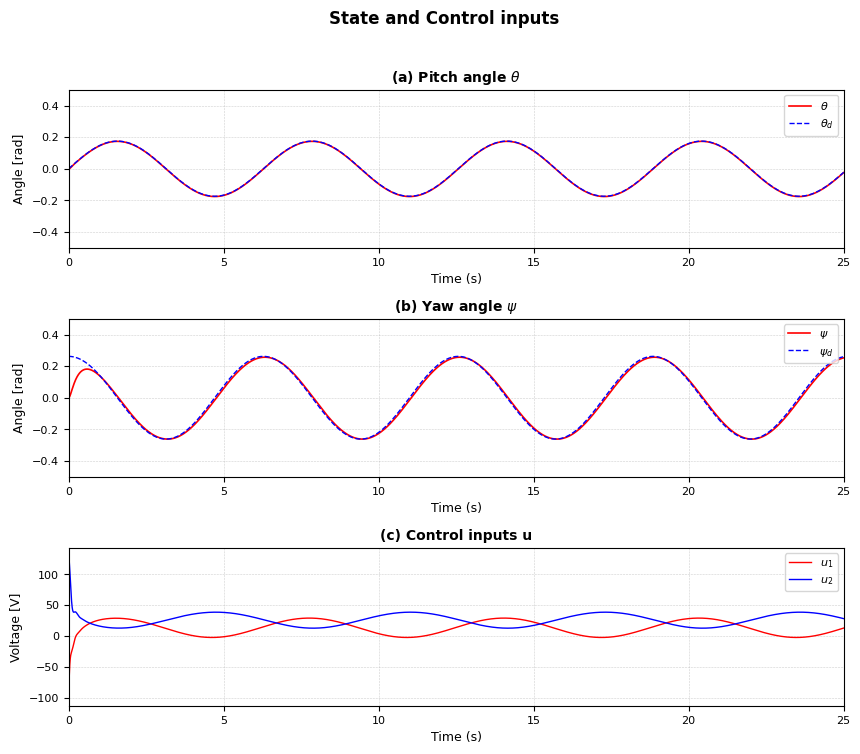

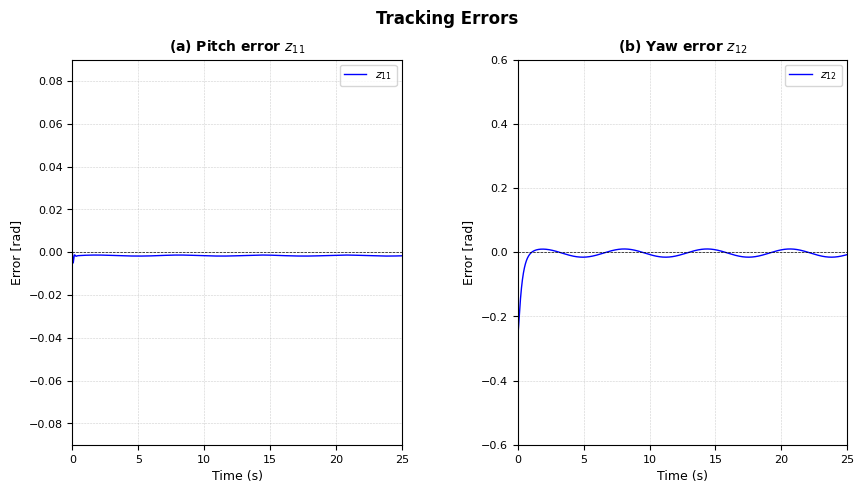

In [752]:
DT = 0.001    # integration step [s]
T  = 25.0     # simulation duration [s]

heli = run_rlc(dt=DT, T=T, seed=42)
plot_results(heli)

## References

[1] Zhao et al., "Reinforcement Learning Control for a 2-DOF Helicopter With State Constraints: Theory and Experiments" IEEE Trans. Autom. Sci. Eng., Vol. 21, No. 1, Jan 2024. [DOI: 10.1109/TASE.2022.3215738](https://cogno.pusan.ac.kr/sites/cogno/2024/2024_260.pdf)